# Pràctica 4 – Part 2B: Avaluació Extrínseca (Spanish STS)

Comparem tres aproximacions per mesurar la similitud entre frases:
1. **Baseline Cosinus** — mitjana simple i TF-IDF dels embeddings estàtics
2. **Model Seqüencial Siamès** — BiLSTM + Atenció sobre embeddings estàtics
3. **Model BERT Siamès** — BETO (BERT en espanyol) + MLP de regressió

**Mètrica**: correlació de Pearson contra les puntuacions humanes del Spanish STS.

## 0. Instal·lació

## 1. Imports

In [2]:
import re, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import pearsonr
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from gensim.models import Word2Vec, FastText as GensimFastText

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel

from datasets import load_dataset

MODELS_DIR = Path("models")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cpu


## 2. Càrrega del dataset Spanish STS

In [5]:
sts = load_dataset("PlanTL-GOB-ES/sts-es")
train_df = sts["train"].to_pandas().rename(columns={"label": "score"})
val_df   = sts["validation"].to_pandas().rename(columns={"label": "score"})
test_df  = sts["test"].to_pandas().rename(columns={"label": "score"})

print(f"Train: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}")
print(test_df[["sentence1","sentence2","score"]].head(3))

Train: 1320  Val: 77  Test: 155
                                           sentence1  \
0  El viceministro de Política Interior y Segurid...   
1  Al mismo asistirán el ministro de Trabajo, Car...   
2  Venus es normalmente conocido como la estrella...   

                                           sentence2  score  
0  En la sede del Alto Comisionado de la ONU para...    1.4  
1  Es el caso del ministro de Trabajo y Seguridad...    1.8  
2  Venus es el astro más característico en los ci...    3.4  


## 3. Càrrega dels models entrenats

In [7]:
with open(MODELS_DIR / "results.pkl", "rb") as f:
    results = pickle.load(f)

wv_models = {}
for r in results:
    name = r["name"]
    model_type = r.get("model_type") or r.get("type")
    path = MODELS_DIR / f"{name}.model"
    try:
        if model_type == "Word2Vec":
            wv_models[name] = Word2Vec.load(str(path)).wv
        else:
            wv_models[name] = GensimFastText.load(str(path)).wv
        print(f"  OK  {name}")
    except Exception as e:
        print(f"  --  {name}  ({e})")
print(f"\nModels carregats: {len(wv_models)}")

  OK  w2v_dim25_tok100k
  OK  ft_dim25_tok100k
  OK  w2v_dim50_tok100k
  OK  ft_dim50_tok100k
  OK  w2v_dim100_tok100k
  OK  ft_dim100_tok100k
  OK  w2v_dim25_tok500k
  OK  ft_dim25_tok500k
  OK  w2v_dim50_tok500k
  OK  ft_dim50_tok500k
  OK  w2v_dim100_tok500k
  OK  ft_dim100_tok500k
  OK  w2v_dim25_tok1000k
  OK  ft_dim25_tok1000k
  OK  w2v_dim50_tok1000k
  OK  ft_dim50_tok1000k
  OK  w2v_dim100_tok1000k
  OK  ft_dim100_tok1000k
  OK  w2v_dim25_tok5000k
  OK  ft_dim25_tok5000k
  OK  w2v_dim50_tok5000k
  OK  ft_dim50_tok5000k
  OK  w2v_dim100_tok5000k
  OK  ft_dim100_tok5000k

Models carregats: 24


## 4. Preprocessat de frases

In [8]:
_PUNCT = re.compile(r"[^\w\s]", re.UNICODE)
_SPACE = re.compile(r"\s+")

def tokenize(text):
    text = text.lower()
    text = _PUNCT.sub(" ", text)
    return _SPACE.sub(" ", text).strip().split()

---
## Part A — Baseline Cosinus

Per cada parell de frases:
1. Tokenitzar les frases
2. Obtenir el vector de cada token
3. Agregar els vectors (mitjana simple o ponderada TF-IDF)
4. Calcular la similitud cosinus entre els dos vectors de frase
5. Avaluar amb correlació de Pearson

### 5. Representació de frases

In [9]:
def sent_vector_mean(text, wv):
    """Mitjana simple dels embeddings de les paraules."""    
    vecs = [wv[t] for t in tokenize(text) if t in wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(wv.vector_size)

def build_tfidf(sentences):
    """Entrena TF-IDF sobre un conjunt de frases."""    
    vectorizer = TfidfVectorizer(use_idf=True, smooth_idf=True, norm=None)
    vectorizer.fit(sentences)
    return vectorizer

def sent_vector_tfidf(text, wv, vectorizer):
    """Mitjana ponderada per TF-IDF."""    
    row = vectorizer.transform([text])
    feat = np.array(vectorizer.get_feature_names_out())
    weighted, total = np.zeros(wv.vector_size, dtype=np.float32), 0.0
    for idx, score in zip(row.indices, row.data):
        w = feat[idx]
        if w in wv:
            weighted += score * wv[w]
            total    += score
    return weighted / total if total > 0 else sent_vector_mean(text, wv)

### 6. Avaluació baseline

In [10]:
def evalua_baseline(wv, df, mode="mean", vectorizer=None):
    human, preds = [], []
    for _, row in df.iterrows():
        if mode == "tfidf":
            v1 = sent_vector_tfidf(row["sentence1"], wv, vectorizer)
            v2 = sent_vector_tfidf(row["sentence2"], wv, vectorizer)
        else:
            v1 = sent_vector_mean(row["sentence1"], wv)
            v2 = sent_vector_mean(row["sentence2"], wv)
        if np.linalg.norm(v1) == 0 or np.linalg.norm(v2) == 0:
            continue
        preds.append(float(cosine_similarity([v1],[v2])[0][0]))
        human.append(row["score"])
    r, _ = pearsonr(human, preds)
    return round(r, 4)

# TF-IDF entrenat sobre totes les frases del test
all_sents = list(test_df["sentence1"]) + list(test_df["sentence2"])
vectorizer = build_tfidf(all_sents)

baseline_results = []
for name, wv in wv_models.items():
    r_mean  = evalua_baseline(wv, test_df, mode="mean")
    r_tfidf = evalua_baseline(wv, test_df, mode="tfidf", vectorizer=vectorizer)
    baseline_results.append({"name": name, "mean": r_mean, "tfidf": r_tfidf})
    print(f"{name:<32}  mean={r_mean:.4f}  tfidf={r_tfidf:.4f}")

df_baseline = pd.DataFrame(baseline_results).sort_values("tfidf", ascending=False)

w2v_dim25_tok100k                 mean=0.4183  tfidf=0.3531
ft_dim25_tok100k                  mean=0.4273  tfidf=0.3983
w2v_dim50_tok100k                 mean=0.4489  tfidf=0.3704
ft_dim50_tok100k                  mean=0.3935  tfidf=0.3732
w2v_dim100_tok100k                mean=0.4189  tfidf=0.3441
ft_dim100_tok100k                 mean=0.3997  tfidf=0.3784
w2v_dim25_tok500k                 mean=0.4429  tfidf=0.3725
ft_dim25_tok500k                  mean=0.4477  tfidf=0.4561
w2v_dim50_tok500k                 mean=0.4764  tfidf=0.3864
ft_dim50_tok500k                  mean=0.4810  tfidf=0.4729
w2v_dim100_tok500k                mean=0.4866  tfidf=0.3871
ft_dim100_tok500k                 mean=0.4890  tfidf=0.4736
w2v_dim25_tok1000k                mean=0.4886  tfidf=0.4654
ft_dim25_tok1000k                 mean=0.4949  tfidf=0.4974
w2v_dim50_tok1000k                mean=0.5517  tfidf=0.4928
ft_dim50_tok1000k                 mean=0.5384  tfidf=0.5213
w2v_dim100_tok1000k               mean=0

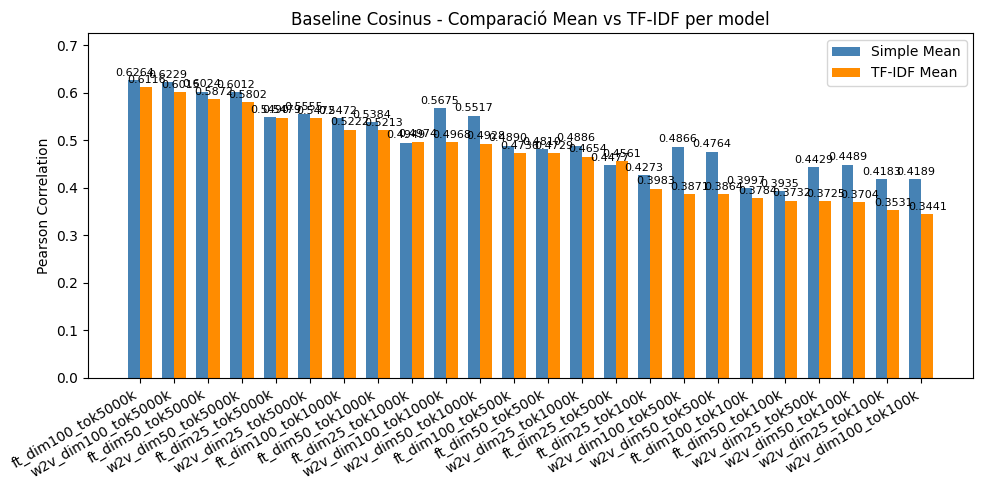

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# --- Gràfic 1: Bar plot comparació mean vs tfidf per model ---
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(df_baseline))
width = 0.35

bars1 = ax.bar(x - width/2, df_baseline["mean"], width, label="Simple Mean", color="steelblue")
bars2 = ax.bar(x + width/2, df_baseline["tfidf"], width, label="TF-IDF Mean", color="darkorange")

ax.set_xticks(x)
ax.set_xticklabels(df_baseline["name"], rotation=30, ha="right")
ax.set_ylabel("Pearson Correlation")
ax.set_title("Baseline Cosinus - Comparació Mean vs TF-IDF per model")
ax.legend()
ax.set_ylim(0, max(df_baseline[["mean","tfidf"]].max()) + 0.1)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{bar.get_height():.4f}", ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{bar.get_height():.4f}", ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()


---
## Part B — Model Seqüencial Siamès (BiLSTM + Atenció)

**Arquitectura**: Embedding → BiLSTM → Atenció → MLP de regressió → similitud  
**Input**: dues seqüències d'índexs de paraules  
**Embeddings**: pre-entrenats (entrenables o congelats)

### 7. Tokenització i vocabulari

In [15]:
# Construïm el vocabulari a partir de les frases del dataset STS
# Tokens especials: <PAD>=0, <UNK>=1
all_words = set()
for df in [train_df, dev_df, test_df]:
    for col in ["sentence1", "sentence2"]:
        for sent in df[col]:
            all_words.update(tokenize(sent))

word2idx = {"<PAD>": 0, "<UNK>": 1}
for w in sorted(all_words):
    word2idx[w] = len(word2idx)

idx2word = {v: k for k, v in word2idx.items()}
VOCAB_SIZE = len(word2idx)
print(f"Vocabulari STS: {VOCAB_SIZE:,} paraules")

def encode(text, max_len=50):
    """Converteix una frase a seqüència d'índexs amb padding."""   
    tokens = tokenize(text)[:max_len]
    ids    = [word2idx.get(t, 1) for t in tokens]  # 1 = <UNK>
    mask   = [True] * len(ids)
    # Padding
    while len(ids) < max_len:
        ids.append(0); mask.append(False)
    return ids, mask

Vocabulari STS: 11,906 paraules


### 8. Matriu d'embeddings pre-entrenats

In [16]:
def build_embedding_matrix(wv, word2idx, dim):
    """
    Construeix la matriu d'embeddings (VOCAB_SIZE x dim)
    a partir del model Gensim, alineada amb el vocabulari del dataset STS.
    Paraules OOV reben un vector aleatori petit.
    """    
    matrix = np.random.uniform(-0.1, 0.1, (len(word2idx), dim)).astype(np.float32)
    matrix[0] = 0  # <PAD> = zeros
    found = 0
    for word, idx in word2idx.items():
        if word in wv:
            matrix[idx] = wv[word]
            found += 1
    print(f"  Cobertura: {found}/{len(word2idx)} ({100*found/len(word2idx):.1f}%)")
    return matrix

# Fem servir el model FastText ft_dim100_tok5000k
wv_seq = wv_models["ft_dim100_tok5000k"]
EMB_DIM = wv_seq.vector_size

print(f"Model per al seqüencial: ft_dim100_tok5000k  (dim={EMB_DIM})")
emb_matrix = build_embedding_matrix(wv_seq, word2idx, EMB_DIM)

Model per al seqüencial: ft_dim100_tok5000k  (dim=100)
  Cobertura: 11906/11906 (100.0%)


### 9. Dataset PyTorch

In [17]:
MAX_LEN = 50

class STSDataset(Dataset):
    def __init__(self, df):
        self.data = df.reset_index(drop=True)
    def __len__(self):
        return len(self.data)
    def __getitem__(self, i):
        row = self.data.iloc[i]
        ids1, mask1 = encode(row["sentence1"], MAX_LEN)
        ids2, mask2 = encode(row["sentence2"], MAX_LEN)
        return (
            torch.tensor(ids1),  torch.tensor(mask1),
            torch.tensor(ids2),  torch.tensor(mask2),
            torch.tensor(row["score"], dtype=torch.float),
        )

train_loader = DataLoader(STSDataset(train_df), batch_size=32, shuffle=True)
dev_loader   = DataLoader(STSDataset(dev_df),   batch_size=64)
test_loader  = DataLoader(STSDataset(test_df),  batch_size=64)

### 10. Arquitectura del model seqüencial

In [18]:
class AttentionPooling(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1)
        )
    def forward(self, x, mask):
        scores = self.proj(x).squeeze(-1)
        scores = scores.masked_fill(~mask, -1e9)
        alpha  = torch.softmax(scores, dim=-1)
        return torch.sum(x * alpha.unsqueeze(-1), dim=1)


class SiameseBiLSTMAttention(nn.Module):
    def __init__(self, embedding_matrix, hidden_size=64, final_hidden_size=32,
                 trainable_embeddings=False):
        super().__init__()
        self.embedding = nn.Embedding.from_pretrained(
            torch.tensor(embedding_matrix, dtype=torch.float),
            freeze=not trainable_embeddings,
            padding_idx=0,
        )
        emb_dim = embedding_matrix.shape[1]
        self.encoder = nn.LSTM(emb_dim, hidden_size, batch_first=True,
                               bidirectional=True)
        self.pool = AttentionPooling(hidden_size * 2)
        self.regressor = nn.Sequential(
            nn.Linear(hidden_size * 2 * 4, final_hidden_size),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(final_hidden_size, 1),
        )

    def encode(self, input_ids, mask):
        x = self.embedding(input_ids)
        x, _ = self.encoder(x)
        return self.pool(x, mask)

    def forward(self, ids1, mask1, ids2, mask2):
        h1 = self.encode(ids1, mask1)
        h2 = self.encode(ids2, mask2)
        feats = torch.cat([h1, h2, torch.abs(h1-h2), h1*h2], dim=-1)
        return self.regressor(feats).squeeze(-1)

### 11. Entrenament del model seqüencial

In [19]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for ids1, mask1, ids2, mask2, scores in loader:
        ids1,mask1,ids2,mask2,scores = (x.to(DEVICE) for x in
                                        (ids1,mask1,ids2,mask2,scores))
        optimizer.zero_grad()
        preds = model(ids1, mask1, ids2, mask2)
        loss  = criterion(preds, scores)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def evaluate(model, loader):
    model.eval()
    all_preds, all_scores = [], []
    with torch.no_grad():
        for ids1, mask1, ids2, mask2, scores in loader:
            ids1,mask1,ids2,mask2 = (x.to(DEVICE) for x in (ids1,mask1,ids2,mask2))
            preds = model(ids1, mask1, ids2, mask2).cpu().numpy()
            all_preds.extend(preds)
            all_scores.extend(scores.numpy())
    r, _ = pearsonr(all_scores, all_preds)
    return round(r, 4)

# ── Entrenar dues variants: embeddings congelats i entrenables ──────────────
seq_results = {}
EPOCHS_SEQ  = 10

for trainable in [False, True]:
    label = "trainable" if trainable else "frozen"
    print(f"\n── BiLSTM embeddings {label} ──")
    model = SiameseBiLSTMAttention(emb_matrix, trainable_embeddings=trainable).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.MSELoss()

    best_dev, best_test = -1, -1
    for epoch in range(1, EPOCHS_SEQ+1):
        loss = train_epoch(model, train_loader, optimizer, criterion)
        dev_r = evaluate(model, dev_loader)
        if dev_r > best_dev:
            best_dev  = dev_r
            best_test = evaluate(model, test_loader)
        if epoch % 2 == 0:
            print(f"  Epoch {epoch:2d}  loss={loss:.4f}  dev_pearson={dev_r:.4f}")

    seq_results[label] = best_test
    print(f"  → Millor test Pearson: {best_test:.4f}")


── BiLSTM embeddings frozen ──
  Epoch  2  loss=1.1141  dev_pearson=0.3332
  Epoch  4  loss=1.0968  dev_pearson=0.4136
  Epoch  6  loss=0.9506  dev_pearson=0.5398
  Epoch  8  loss=0.8001  dev_pearson=0.5204
  Epoch 10  loss=0.6016  dev_pearson=0.5519
  → Millor test Pearson: 0.6128

── BiLSTM embeddings trainable ──
  Epoch  2  loss=1.1532  dev_pearson=0.2803
  Epoch  4  loss=1.0233  dev_pearson=0.3776
  Epoch  6  loss=0.5707  dev_pearson=0.3565
  Epoch  8  loss=0.3193  dev_pearson=0.3365
  Epoch 10  loss=0.2478  dev_pearson=0.4013
  → Millor test Pearson: 0.4902


---
## Part C — Model BERT Siamès (BETO)

**Arquitectura**: BETO → MeanPooling → MLP de regressió → similitud  
**Model base**: `dccuchile/bert-base-spanish-wwm-cased`

### 12. Tokenització BERT i Dataset

In [ ]:
BERT_MODEL = "dccuchile/bert-base-spanish-wwm-cased"
tokenizer_bert = AutoTokenizer.from_pretrained(BERT_MODEL)

class STSDatasetBERT(Dataset):
    def __init__(self, df, tokenizer, max_len=128):
        self.data      = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self): return len(self.data)

    def __getitem__(self, i):
        row = self.data.iloc[i]
        def enc(text):
            return self.tokenizer(text, max_length=self.max_len, padding="max_length",
                                  truncation=True, return_tensors="pt")
        e1 = enc(row["sentence1"])
        e2 = enc(row["sentence2"])
        return (
            e1["input_ids"].squeeze(),    e1["attention_mask"].squeeze(),
            e2["input_ids"].squeeze(),    e2["attention_mask"].squeeze(),
            torch.tensor(row["score"], dtype=torch.float),
        )

train_bert = DataLoader(STSDatasetBERT(train_df, tokenizer_bert), batch_size=16, shuffle=True)
dev_bert   = DataLoader(STSDatasetBERT(dev_df,   tokenizer_bert), batch_size=32)
test_bert  = DataLoader(STSDatasetBERT(test_df,  tokenizer_bert), batch_size=32)

### 13. Arquitectura BERT Siamès

In [21]:
class MeanPooling(nn.Module):
    def forward(self, last_hidden_state, attention_mask):
        mask = attention_mask.unsqueeze(-1).float()
        return (last_hidden_state * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1e-9)


class BETOSiameseRegressor(nn.Module):
    def __init__(self, model_name=BERT_MODEL, final_hidden_size=64):
        super().__init__()
        self.encoder    = AutoModel.from_pretrained(model_name)
        self.pool       = MeanPooling()
        hidden          = self.encoder.config.hidden_size
        self.regressor  = nn.Sequential(
            nn.Linear(hidden * 4, final_hidden_size),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(final_hidden_size, 1),
        )

    def encode(self, input_ids, attention_mask):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        return self.pool(out.last_hidden_state, attention_mask)

    def forward(self, ids1, mask1, ids2, mask2):
        h1    = self.encode(ids1, mask1)
        h2    = self.encode(ids2, mask2)
        feats = torch.cat([h1, h2, torch.abs(h1-h2), h1*h2], dim=-1)
        return self.regressor(feats).squeeze(-1)

### 14. Entrenament del model BERT

In [ ]:
bert_model = BETOSiameseRegressor().to(DEVICE)
optimizer_bert = torch.optim.AdamW(bert_model.parameters(), lr=2e-5)
criterion_bert = nn.MSELoss()
EPOCHS_BERT = 3  # BERT necessita menys epochs

best_dev_bert, best_test_bert = -1, -1
for epoch in range(1, EPOCHS_BERT+1):
    loss = train_epoch(bert_model, train_bert, optimizer_bert, criterion_bert)
    dev_r = evaluate(bert_model, dev_bert)
    if dev_r > best_dev_bert:
        best_dev_bert  = dev_r
        best_test_bert = evaluate(bert_model, test_bert)
    print(f"Epoch {epoch}  loss={loss:.4f}  dev_pearson={dev_r:.4f}")

print(f"\nMillor test Pearson BERT: {best_test_bert:.4f}")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
pooler.dense.bias                          | MISSING    | 
pooler.dense.weight                        | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1  loss=8.6573  dev_pearson=-0.0422

Millor test Pearson BERT: 0.1007


---
## 15. Resum final de totes les aproximacions

In [ ]:
# Millor baseline (TF-IDF)
best_bl = df_baseline.iloc[0]

print("="*55)
print(f"{'Aproximació':<35} {'Pearson':>8}")
print("="*55)
print(f"{'Baseline mean (' + best_bl['name'] + ')':<35} {best_bl['mean']:>8.4f}")
print(f"{'Baseline TF-IDF (' + best_bl['name'] + ')':<35} {best_bl['tfidf']:>8.4f}")
print(f"{'BiLSTM frozen (' + SEQ_MODEL_NAME + ')':<35} {seq_results['frozen']:>8.4f}")
print(f"{'BiLSTM trainable (' + SEQ_MODEL_NAME + ')':<35} {seq_results['trainable']:>8.4f}")
print(f"{'BETO Siamès':<35} {best_test_bert:>8.4f}")
print("="*55)

# Gràfic
labels = ["Baseline\nmean", "Baseline\nTF-IDF",
          "BiLSTM\nfrozen", "BiLSTM\ntrainable", "BETO\nSiamès"]
values = [best_bl["mean"], best_bl["tfidf"],
          seq_results["frozen"], seq_results["trainable"], best_test_bert]
colors = ["#4878cf","#4878cf","#6acc65","#6acc65","#d65f5f"]

fig, ax = plt.subplots(figsize=(9,4))
ax.bar(labels, values, color=colors, alpha=0.85)
ax.set_ylabel("Pearson r")
ax.set_title("Avaluació extrínseca – Spanish STS\n(totes les aproximacions)")
ax.set_ylim(0, 1)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("grafic_extrinseca.png", dpi=120, bbox_inches="tight")
plt.show()